# JOINTS 2026 Baseline Notebook

Objective: Memprediksi penjualan tiket harian D4-D10 untuk setiap pasangan film dan klaster bioskop berdasarkan penjualan D1-D3 dengan menggunakan MASE sebagai metrik evaluasi.

# Sinkronisasi versi modules dan libraries

In [1]:
import sys; print(sys.version)
%pip install -q --no-warn-script-location \
    numpy==2.4.4 pandas==2.3.3 scikit-learn==1.8.0 lightgbm==4.6.0 matplotlib==3.10.9 joblib==1.5.3

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\leouw\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Import modules dan libraries

In [2]:
import os, glob, random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from lightgbm import LGBMRegressor

### Random state
Menetapkan satu konstanta SEED untuk semua bagian yang memakai randomness agar hasil prediksi bisa dibuat ulang oleh panitia.

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print("SEED =", SEED)

SEED = 42


# Import datasets

In [4]:
_DATA_DIR_CANDIDATES = [
    "../data", "data", "../../data",
    *glob.glob("/kaggle/input/*"), *glob.glob("/kaggle/input/**/", recursive=True),
]
DATA_DIR = next((d for d in _DATA_DIR_CANDIDATES if d and os.path.exists(os.path.join(d, "test_history.csv"))), None)
if DATA_DIR is None:
    raise FileNotFoundError("test_history.csv not found in any candidate DATA_DIR - set it manually.")
print("DATA_DIR =", os.path.abspath(DATA_DIR))

train = pd.read_csv(f"{DATA_DIR}/train.csv", parse_dates=["date_show"])
test_hist = pd.read_csv(f"{DATA_DIR}/test_history.csv", parse_dates=["date_show"])
test = pd.read_csv(f"{DATA_DIR}/test.csv", parse_dates=["date_show"])
sample_sub = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")
movies = pd.read_csv(f"{DATA_DIR}/movies.csv")
holidays = pd.read_csv(f"{DATA_DIR}/holidays.csv", parse_dates=["date"])
prices = pd.read_csv(f"{DATA_DIR}/ticket_prices.csv")

DATA_DIR = c:\MyFolder\Coding\Data Science\Lomba\JOINTS\JOINTS\data


# EDA

In [5]:
for name, df in {"train": train, "test_history": test_hist, "test": test, "movies": movies,
                 "holidays": holidays, "prices": prices}.items():
    print(f"{name}: {df.shape}")
print("train movies:", train["movie_title"].nunique(), "| test movies:", test["movie_title"].nunique(),
      "| overlap:", len(set(train["movie_title"]) & set(test["movie_title"])))
train.head()

train: (138959, 7)
test_history: (32323, 7)
test: (72611, 5)
movies: (397, 7)
holidays: (366, 4)
prices: (207, 3)
train movies: 237 | test movies: 160 | overlap: 10


,date_show,cinema_ids,city_name,movie_title,total_ticket,occupation_rate,total_show
0,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,A WORKING MAN,487,31.07,18
1,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,JUMBO,649,23.69,19
2,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,KOMANG,389,9.55,22
3,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,NE ZHA 2,101,70.03,3
4,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,NORMA: ANTARA MERTUA DAN MENANTU,411,17.76,13


### Distribusi tiket harian
Sebaran total_ticket dilihat dalam skala log karena nilainya sangat timpang antar film dan klaster.

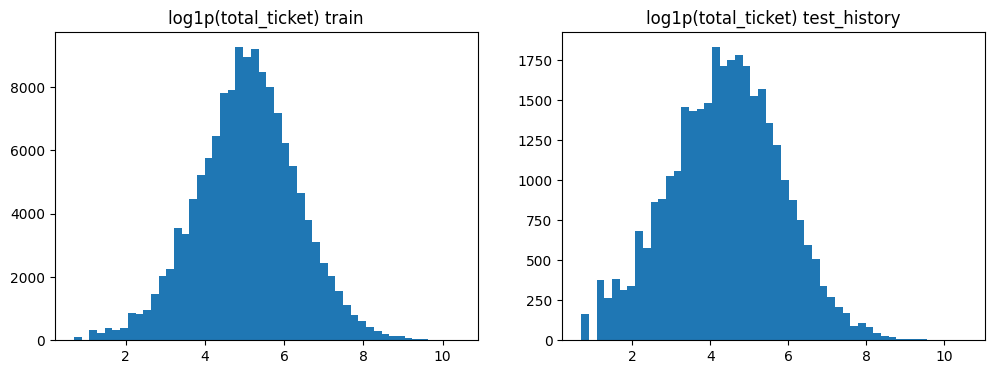

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(np.log1p(train["total_ticket"]), bins=50)
ax[0].set_title("log1p(total_ticket) train")
ax[1].hist(np.log1p(test_hist["total_ticket"]), bins=50)
ax[1].set_title("log1p(total_ticket) test_history")
plt.show()

### Jumlah klaster per hari untuk tiap film
Film biasanya punya beberapa hari preview di sedikit klaster sebelum tayang luas, pola ini dipakai untuk menentukan D1 pada train.

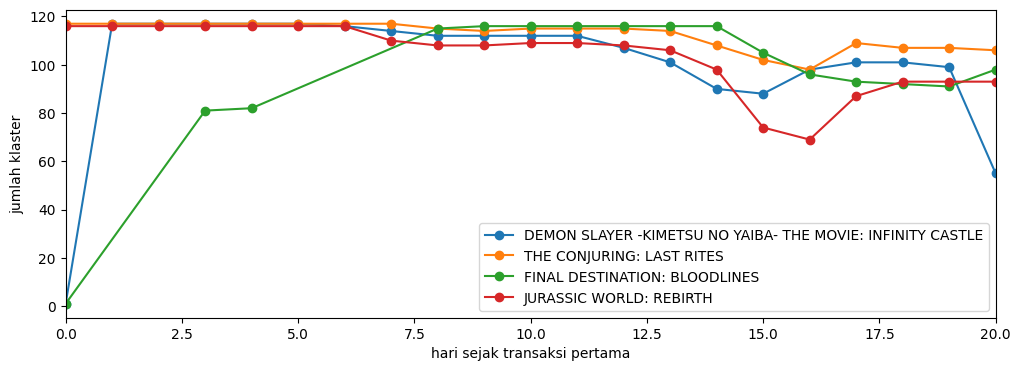

In [7]:
clusters_per_day = train.groupby(["movie_title", "date_show"])["cinema_ids"].nunique()
first_date = train.groupby("movie_title")["date_show"].min()
max_clusters = clusters_per_day.groupby(level=0).max()
examples = max_clusters[first_date > first_date.min()].nlargest(4).index

fig, ax = plt.subplots(figsize=(12, 4))
for title in examples:
    s = clusters_per_day[title]
    ax.plot((s.index - s.index.min()).days, s.values, marker="o", label=title)
ax.set_xlim(0, 20)
ax.set_xlabel("hari sejak transaksi pertama")
ax.set_ylabel("jumlah klaster")
ax.legend()
plt.show()

### Penjualan per hari dalam minggu

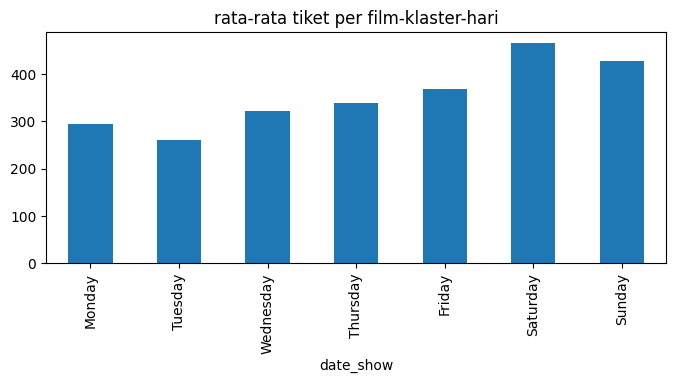

In [8]:
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
train.groupby(train["date_show"].dt.day_name())["total_ticket"].mean().reindex(DAY_ORDER).plot(
    kind="bar", figsize=(8, 3), title="rata-rata tiket per film-klaster-hari"
)
plt.show()

# Aggregate
Mengubah riwayat transaksi train menjadi sampel dengan format yang sama seperti test, yaitu penjualan D1-D3 sebagai input dan D4-D10 sebagai target untuk setiap pasangan film dan klaster.

### Penentuan D1
D1 pada train adalah tanggal pertama film tayang di minimal 50% dari jumlah klaster maksimalnya, agar hari preview tidak dihitung sebagai D1 seperti pada data test. Film yang sudah tayang sejak awal data atau belum mencapai D10 sebelum data berakhir dibuang.

In [9]:
D1_MIN_SHARE = 0.5

wide_days = clusters_per_day[clusters_per_day >= D1_MIN_SHARE * clusters_per_day.groupby(level=0).transform("max")]
train_d1 = wide_days.reset_index().groupby("movie_title")["date_show"].min()
train_d1 = train_d1[
    (first_date[train_d1.index] > train["date_show"].min())
    & (train_d1 + pd.Timedelta(days=9) <= train["date_show"].max())
]
test_d1 = test.groupby("movie_title")["date_show"].min() - pd.Timedelta(days=3)

print(f"train movies: {len(train_d1)} | test movies: {len(test_d1)}")
print("test D1 sama dengan tanggal pertama test_history:",
      (test_hist.groupby("movie_title")["date_show"].min().reindex(test_d1.index) == test_d1).mean().round(3))

train movies: 205 | test movies: 160
test D1 sama dengan tanggal pertama test_history: 1.0


### Pembentukan pasangan film-klaster
Mengambil transaksi D1-D10 setiap film dan mengisi hari tanpa transaksi dengan 0. Pasangan train hanya diambil jika masih ada penjualan di D3, mengikuti test yang hanya berisi pasangan yang masih tayang di D3.

In [10]:
PIVOT_COLS = {"total_ticket": "t", "occupation_rate": "occ", "total_show": "show"}
CLUSTER_CITY = pd.concat([train, test_hist]).drop_duplicates("cinema_ids").set_index("cinema_ids")["city_name"]

def build_window(hist, d1_map, n_days):
    df = hist[hist["movie_title"].isin(d1_map.index)].copy()
    df["day"] = (df["date_show"] - df["movie_title"].map(d1_map)).dt.days + 1
    df = df[df["day"].between(1, n_days)]
    parts = []
    for col, prefix in PIVOT_COLS.items():
        p = df.pivot_table(index=["movie_title", "cinema_ids"], columns="day", values=col, fill_value=0)
        p = p.reindex(columns=range(1, n_days + 1), fill_value=0)
        p.columns = [f"{prefix}{d}" for d in p.columns]
        parts.append(p)
    out = pd.concat(parts, axis=1).reset_index()
    out["d1_date"] = out["movie_title"].map(d1_map)
    return out

train_window = build_window(train, train_d1, 10)
test_window = build_window(test_hist, test_d1, 3)

train_pairs = train_window[train_window["t3"] > 0].reset_index(drop=True)
test_pairs = test_window.merge(test[["movie_title", "cinema_ids"]].drop_duplicates(), on=["movie_title", "cinema_ids"])

print(f"train pairs: {len(train_pairs)} | test pairs: {len(test_pairs)}")
train_pairs.head()

train pairs: 8007 | test pairs: 10373


,movie_title,cinema_ids,t1,t2,t3,t4,t5,t6,t7,t8,...,show2,show3,show4,show5,show6,show7,show8,show9,show10,d1_date
0,28 YEARS LATER,015555fbcd8faef6b55a854605df0a87,261.0,210.0,137.0,52.0,62.0,26.0,14.0,0.0,...,17.0,12.0,2.0,5.0,4.0,2.0,0.0,0.0,0.0,2025-06-18
1,28 YEARS LATER,0191582d75f94a412c0fa12d36bcee3f,1376.0,1033.0,946.0,1455.0,1103.0,804.0,576.0,548.0,...,23.0,23.0,23.0,24.0,24.0,23.0,15.0,15.0,15.0,2025-06-18
2,28 YEARS LATER,04a2de432a8901363a05137a8e8de1d2,0.0,83.0,85.0,77.0,76.0,35.0,0.0,0.0,...,3.0,3.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,2025-06-18
3,28 YEARS LATER,073b764928864ed8fa0b6b115bfdd685,159.0,55.0,43.0,77.0,45.0,40.0,36.0,0.0,...,3.0,2.0,2.0,3.0,2.0,2.0,0.0,0.0,0.0,2025-06-18
4,28 YEARS LATER,108f9a4d181f12fd1b7e3c9adae38478,643.0,458.0,447.0,850.0,718.0,357.0,295.0,366.0,...,19.0,20.0,19.0,17.0,18.0,16.0,17.0,9.0,7.0,2025-06-18


### Pasangan ke format harian
Mengubah setiap pasangan menjadi 7 baris D4-D10 sehingga satu baris mewakili satu tanggal yang diprediksi, sama seperti test.csv.

In [11]:
HORIZONS = range(4, 11)
BASE_COLS = ["movie_title", "cinema_ids", "d1_date"] + [f"{p}{d}" for p in PIVOT_COLS.values() for d in (1, 2, 3)]

def to_long(pairs, with_target):
    rows = []
    for h in HORIZONS:
        r = pairs[BASE_COLS].copy()
        r["horizon"] = h
        r["date_show"] = r["d1_date"] + pd.Timedelta(days=h - 1)
        if with_target:
            r["total_ticket"] = pairs[f"t{h}"].values
        rows.append(r)
    return pd.concat(rows, ignore_index=True)

train_long = to_long(train_pairs, with_target=True)
test_long = to_long(test_pairs, with_target=False)
print(f"train rows: {len(train_long)} | test rows: {len(test_long)} | test.csv rows: {len(test)}")

train rows: 56049 | test rows: 72611 | test.csv rows: 72611


# Feature Engineering

### Fitur pasangan
Fitur dari penjualan D1-D3 pasangan itu sendiri:
- scale: rata-rata tiket D1-D3 dengan batas bawah 1, sama persis dengan skala pada MASE.
- trend: rasio tiket D3 terhadap D1, untuk melihat penjualan naik atau turun.
- t3_share: porsi tiket D3 dari total D1-D3.
- occ_mean, show_mean: rata-rata okupansi dan jumlah pertunjukan D1-D3.
- tickets_per_show3: rata-rata tiket per pertunjukan pada D3.
- active_days: jumlah hari D1-D3 yang memiliki transaksi.

In [12]:
def add_pair_features(df):
    df["scale"] = df[["t1", "t2", "t3"]].mean(axis=1).clip(lower=1)
    df["trend"] = (df["t3"] + 1) / (df["t1"] + 1)
    df["t3_share"] = df["t3"] / df[["t1", "t2", "t3"]].sum(axis=1)
    df["occ_mean"] = df[["occ1", "occ2", "occ3"]].mean(axis=1)
    df["show_mean"] = df[["show1", "show2", "show3"]].mean(axis=1)
    df["tickets_per_show3"] = df["t3"] / df["show3"].replace(0, np.nan)
    df["active_days"] = (df[["t1", "t2", "t3"]] > 0).sum(axis=1)
    return df

### Fitur film
Fitur tingkat nasional dari seluruh klaster pada D1-D3, karena pola naik turun sebuah film biasanya mirip di semua lokasi:
- mv_t1, mv_t2, mv_t3: total tiket nasional per hari.
- mv_trend: rasio total nasional D3 terhadap D1.
- mv_clusters: jumlah klaster yang masih menjual tiket pada D3.
- pair_share: porsi penjualan pasangan dari total nasional film.

In [13]:
def movie_features(window):
    g = window.groupby("movie_title")
    mv = g[["t1", "t2", "t3"]].sum().add_prefix("mv_")
    mv["mv_clusters"] = g["t3"].apply(lambda s: (s > 0).sum())
    mv["mv_trend"] = (mv["mv_t3"] + 1) / (mv["mv_t1"] + 1)
    return mv.reset_index()

### Fitur klaster
Rata-rata skala D1-D3 setiap klaster dari semua film di train dan test_history, sebagai ukuran besar kecilnya klaster tanpa memakai target D4-D10.

In [14]:
all_windows = pd.concat([train_window, test_window], ignore_index=True)
cluster_feats = (
    all_windows.assign(pair_scale=all_windows[["t1", "t2", "t3"]].mean(axis=1))
    .groupby("cinema_ids")
    .agg(cl_scale=("pair_scale", "mean"), cl_movies=("movie_title", "nunique"))
    .reset_index()
)
cluster_feats.describe()

,cl_scale,cl_movies
count,121.000000,121.000000
mean,193.417838,191.801653
std,166.640080,73.140916
min,18.771242,5.000000
25%,106.632768,145.000000
50%,160.533333,189.000000
75%,221.977333,237.000000
max,1360.350557,344.000000


### Fitur kalender dan harga
Fitur tanggal target yang memengaruhi jumlah penonton:
- dow, day_tipe, is_holiday: hari dalam minggu, tipe hari, dan status libur tanggal target.
- d1_dow: hari dalam minggu pada D1, karena D1-D3 yang jatuh di akhir pekan membuat skala lebih tinggi.
- price: harga tiket kota pada tanggal target.
- price_ratio: harga tanggal target dibanding rata-rata harga D1-D3.

In [15]:
CALENDAR = holidays.rename(columns={"date": "date_show"})[["date_show", "day_tipe", "holiday_tipe"]]
DAY_TIPE = CALENDAR.set_index("date_show")["day_tipe"]
PRICE_DAY = {"weekday": "Weekday", "friday": "Friday", "weekend": "Weekend"}
PRICE_MAP = prices.set_index(["city_name", "price_day"])["ceil"]

def price_of(city, dates):
    price_day = dates.map(DAY_TIPE).map(PRICE_DAY)
    return pd.Series(PRICE_MAP.reindex(list(zip(city, price_day))).values, index=city.index)

def add_calendar_features(df):
    df = df.merge(CALENDAR, on="date_show", how="left")
    df["dow"] = df["date_show"].dt.dayofweek
    df["d1_dow"] = df["d1_date"].dt.dayofweek
    df["is_holiday"] = (df["holiday_tipe"] == "holiday").astype(int)
    df["price"] = price_of(df["city_name"], df["date_show"])
    d13_price = pd.concat([price_of(df["city_name"], df["d1_date"] + pd.Timedelta(days=k)) for k in range(3)], axis=1)
    df["price_ratio"] = df["price"] / d13_price.mean(axis=1)
    return df

### Penggabungan fitur
Menggabungkan semua fitur di atas ke data train dan test dalam format harian.

In [16]:
def make_features(long, window):
    df = add_pair_features(long.copy())
    df = df.merge(movie_features(window), on="movie_title", how="left")
    df["pair_share"] = df[["t1", "t2", "t3"]].sum(axis=1) / (df["mv_t1"] + df["mv_t2"] + df["mv_t3"])
    df = df.merge(cluster_feats, on="cinema_ids", how="left")
    df["city_name"] = df["cinema_ids"].map(CLUSTER_CITY)
    return add_calendar_features(df)

train_feat = make_features(train_long, train_window)
test_feat = make_features(test_long, test_window)
print(f"train_feat: {train_feat.shape} | test_feat: {test_feat.shape}")
train_feat.head()

train_feat: (56049, 38) | test_feat: (72611, 37)


,movie_title,cinema_ids,d1_date,t1,t2,t3,occ1,occ2,occ3,show1,...,cl_scale,cl_movies,city_name,day_tipe,holiday_tipe,dow,d1_dow,is_holiday,price,price_ratio
0,28 YEARS LATER,015555fbcd8faef6b55a854605df0a87,2025-06-18,261.0,210.0,137.0,13.56,14.30,12.25,18.0,...,383.325301,249,SURABAYA,weekend,normal,5,2,0,45000,1.227273
1,28 YEARS LATER,0191582d75f94a412c0fa12d36bcee3f,2025-06-18,1376.0,1033.0,946.0,39.38,23.87,22.75,23.0,...,526.115079,336,SURABAYA,weekend,normal,5,2,0,45000,1.227273
2,28 YEARS LATER,04a2de432a8901363a05137a8e8de1d2,2025-06-18,0.0,83.0,85.0,0.00,16.10,16.14,0.0,...,113.631455,142,MAMUJU,weekend,normal,5,2,0,40000,1.263158
3,28 YEARS LATER,073b764928864ed8fa0b6b115bfdd685,2025-06-18,159.0,55.0,43.0,19.57,38.15,43.26,9.0,...,262.500000,186,BATAM,weekend,normal,5,2,0,45000,1.227273
4,28 YEARS LATER,108f9a4d181f12fd1b7e3c9adae38478,2025-06-18,643.0,458.0,447.0,12.21,14.42,15.14,30.0,...,579.506091,301,TANGERANG,weekend,normal,5,2,0,55000,1.269231


# Preprocessing

### Target rasio terhadap skala
Target dibagi dengan scale sehingga model memprediksi rasio terhadap rata-rata D1-D3. Dengan objective L1, error pada rasio ini sama persis dengan MASE, jadi model langsung mengoptimalkan metrik lomba.

In [17]:
train_feat["target_ratio"] = train_feat["total_ticket"] / train_feat["scale"]
train_feat.groupby("horizon")["target_ratio"].median()

horizon
4     0.901639
5     0.614685
6     0.460478
7     0.362069
8     0.157407
9     0.000000
10    0.000000
Name: target_ratio, dtype: float64

### Kolom kategori
Mengubah city_name dan day_tipe menjadi tipe category dengan kategori yang sama di train dan test agar bisa langsung dibaca LightGBM.

In [18]:
CAT_COLS = ["city_name", "day_tipe"]
for c in CAT_COLS:
    cats = pd.Categorical(pd.concat([train_feat[c], test_feat[c]])).categories
    train_feat[c] = pd.Categorical(train_feat[c], categories=cats)
    test_feat[c] = pd.Categorical(test_feat[c], categories=cats)
train_feat[CAT_COLS].nunique()

city_name    67
day_tipe      3
dtype: int64

# Regressor Models

### Setup parameter dan validasi
Validasi memakai GroupKFold berdasarkan film supaya film validasi tidak pernah dilihat saat training, sama seperti film test yang hampir semuanya belum ada di train. Jumlah tree dibuat tetap tanpa early stopping pada fold validasi agar skor CV tidak terlalu optimis. Sebagai pembanding dihitung juga MASE dari prediksi naif.

In [19]:
FEATURES = [
    "horizon", "t1", "t2", "t3", "scale", "trend", "t3_share", "occ_mean", "show_mean", "show3",
    "tickets_per_show3", "active_days", "mv_t1", "mv_t2", "mv_t3", "mv_trend", "mv_clusters",
    "pair_share", "cl_scale", "cl_movies", "city_name", "day_tipe", "dow", "d1_dow", "is_holiday",
    "price", "price_ratio",
]
N_FOLDS = 5
LGBM_PARAMS = dict(
    objective="l1", n_estimators=150, learning_rate=0.03, num_leaves=31, min_child_samples=50,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=SEED,
    deterministic=True, force_row_wise=True, verbose=-1,
)

def mase(y_true, y_pred, scale):
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)) / np.asarray(scale))

X, y, groups = train_feat[FEATURES], train_feat["target_ratio"], train_feat["movie_title"]
print(f"naive rata-rata D1-D3: {mase(train_feat['total_ticket'], train_feat['scale'], train_feat['scale']):.4f}")
print(f"naive tiket D3       : {mase(train_feat['total_ticket'], train_feat['t3'], train_feat['scale']):.4f}")
print(f"naive nol            : {mase(train_feat['total_ticket'], 0, train_feat['scale']):.4f}")

naive rata-rata D1-D3: 0.7393
naive tiket D3       : 0.6963
naive nol            : 0.5877


### LGBM Regressor

In [20]:
oof = np.zeros(len(train_feat))
for fold, (tr_idx, va_idx) in enumerate(GroupKFold(n_splits=N_FOLDS).split(X, y, groups)):
    model = LGBMRegressor(**LGBM_PARAMS).fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof[va_idx] = np.clip(model.predict(X.iloc[va_idx]), 0, None)
    print(f"fold {fold}: MASE={np.mean(np.abs(y.iloc[va_idx] - oof[va_idx])):.4f}")

train_feat["oof_ticket"] = oof * train_feat["scale"]
print(f"CV MASE: {mase(train_feat['total_ticket'], train_feat['oof_ticket'], train_feat['scale']):.4f}")

fold 0: MASE=0.4887
fold 1: MASE=0.5304
fold 2: MASE=0.2626
fold 3: MASE=0.3984
fold 4: MASE=0.2662
CV MASE: 0.3893


### MASE per horizon
Melihat error di setiap hari target, biasanya makin jauh dari D3 makin sulit ditebak.

In [21]:
train_feat.assign(err=np.abs(train_feat["total_ticket"] - train_feat["oof_ticket"]) / train_feat["scale"]) \
    .groupby("horizon")["err"].mean().round(4)

horizon
4     0.4475
5     0.4597
6     0.3965
7     0.3696
8     0.3303
9     0.3541
10    0.3672
Name: err, dtype: float64

### Final model
Melatih ulang LGBM di seluruh data train dengan parameter yang sama seperti saat CV.

In [22]:
final_model = LGBMRegressor(**LGBM_PARAMS).fit(X, y)
print("n_estimators =", LGBM_PARAMS["n_estimators"])

n_estimators = 150


### Feature Importance for LGBM

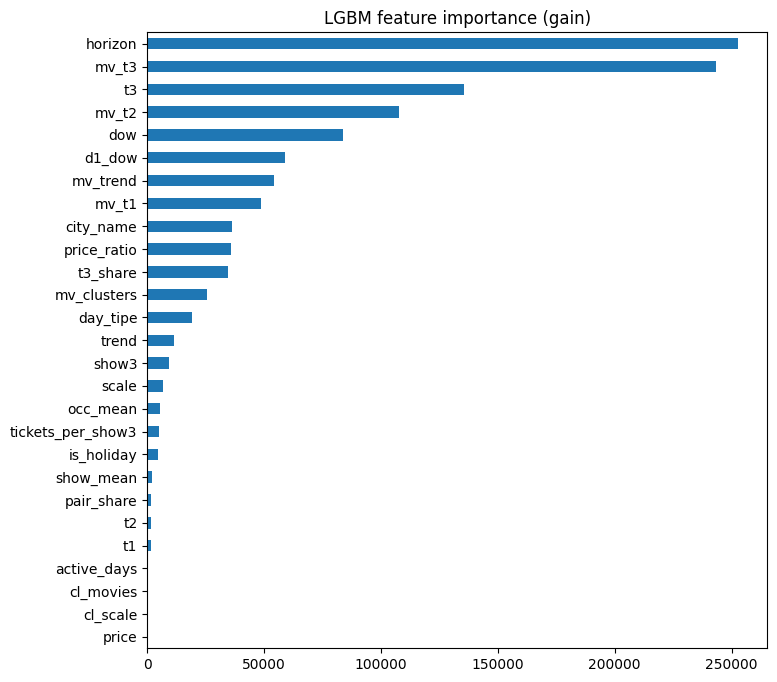

In [23]:
importance = pd.Series(
    final_model.booster_.feature_importance(importance_type="gain"), index=FEATURES
).sort_values()
importance.plot(kind="barh", figsize=(8, 8), title="LGBM feature importance (gain)")
plt.show()

# Postprocessing

### Libur sekolah (data eksternal)
Tanggal libur sekolah dari Kalender Pendidikan DKI Jakarta 2024/2025 dan 2025/2026 (Keputusan Kepala Dinas Pendidikan Jakarta No. 89 Tahun 2025), yang dirilis sebelum 30 September 2025.

In [24]:
SCHOOL_HOLIDAYS = [
    ("2025-03-25", "2025-04-07"), ("2025-06-28", "2025-07-13"), ("2025-12-22", "2026-01-04"),
    ("2026-02-16", "2026-02-20"), ("2026-03-16", "2026-03-27"),
]
SCHOOL_DAYS = pd.DatetimeIndex(np.concatenate([pd.date_range(a, b) for a, b in SCHOOL_HOLIDAYS]))
print("hari libur sekolah:", len(SCHOOL_DAYS))

hari libur sekolah: 61


### Penyesuaian musiman
Train dimulai tepat di hari Lebaran 2025, jadi model tidak pernah melihat film yang D1-D3-nya di akhir Ramadan lalu D4-D10-nya di minggu Lebaran, dan hanya sedikit film train yang kena libur sekolah. Faktor pengali untuk kedua kelompok ini ditentukan dari public LB:
- lebaran: D1-D3 menyentuh Ramadan (mulai 19 Februari 2026) dan tanggal target sudah masuk Lebaran (mulai 20 Maret 2026), x2.0.
- libur_sekolah: D1-D3 dan tanggal target semuanya libur sekolah, x1.25.

In [25]:
RAMADAN_START, LEBARAN_START = pd.Timestamp("2026-02-19"), pd.Timestamp("2026-03-20")
SEASON_FACTORS = {"lebaran": 2.0, "libur_sekolah": 1.25}

def season_factor(df):
    d13 = [df["d1_date"] + pd.Timedelta(days=k) for k in range(3)]
    d13_ramadan = np.any([(d >= RAMADAN_START) & (d < LEBARAN_START) for d in d13], axis=0)
    lebaran = d13_ramadan & (df["date_show"] >= LEBARAN_START)
    school = np.all([d.isin(SCHOOL_DAYS) for d in d13], axis=0) & df["date_show"].isin(SCHOOL_DAYS)
    return np.select([lebaran, school], [SEASON_FACTORS["lebaran"], SEASON_FACTORS["libur_sekolah"]], 1.0)

test_feat["season_factor"] = season_factor(test_feat)
test_feat["total_ticket"] = (
    np.clip(final_model.predict(test_feat[FEATURES]), 0, None) * test_feat["scale"] * test_feat["season_factor"]
)
test_feat["season_factor"].value_counts()

season_factor
1.00    64746
2.00     4598
1.25     3267
Name: count, dtype: int64

# Submission

In [26]:
submission = test.merge(
    test_feat[["movie_title", "cinema_ids", "date_show", "total_ticket"]],
    on=["movie_title", "cinema_ids", "date_show"], how="left",
)[["id", "total_ticket"]]
submission = sample_sub[["id"]].merge(submission, on="id", how="left")
assert len(submission) == len(sample_sub) and submission["total_ticket"].notna().all()
submission.to_csv("submission.csv", index=False)
submission.describe()

,id,total_ticket
count,72611.000000,72611.000000
mean,36306.000000,163.876086
std,20961.134535,670.375721
min,1.000000,0.000000
25%,18153.500000,1.550637
50%,36306.000000,26.805984
75%,54458.500000,126.207084
max,72611.000000,39037.861257
